In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')
print(sys.path)

['/home/hieutt/MRGA-KAN/notebooks', '/home/hieutt/miniconda3/envs/torchtf/lib/python39.zip', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/lib-dynload', '', '/home/hieutt/miniconda3/envs/torchtf/lib/python3.9/site-packages', '../']


In [7]:
from pathlib import Path
import numpy as np
import os
import pandas as pd
import re
import time
from networks.graph_attention_ffn_kan_bottleneckhead_multitask import GraphAttentionKAN
# from networks.graph_attention_ffn_kan_multitask_updated import GraphAttentionKAN 
from networks.graph_attention_ffn_kan_mlphead_multitask import GraphAttentionKAN as GraphAttentionKAN_MLP 
from networks.graph_attention_mlpffn_kanhead_multitask import GraphAttentionKAN as GraphAttentionMLP_KAN 
from networks.graph_attention_mlpffn_mlphead_multitask import GraphAttentionKAN as GraphAttentionMLP_MLP


In [12]:
import pandas as pd

# ============================================================
# 1) Helper
# ============================================================
def count_params(module, trainable_only=True):
    if module is None:
        return 0
    if trainable_only:
        return sum(p.numel() for p in module.parameters() if p.requires_grad)
    return sum(p.numel() for p in module.parameters())

def build_model(model_cls, **kwargs):
    model = model_cls(**kwargs)
    return model

def detect_head_type(head_module):
    cls_name = head_module.__class__.__name__.lower()

    # KAN head thường không phải nn.Sequential, hoặc có tên KAN
    if "kan" in cls_name:
        return "KAN"
    if cls_name == "sequential":
        return "MLP"
    return head_module.__class__.__name__

def summarize_model(name, model):
    total_params = count_params(model)

    graph_head_params = count_params(getattr(model, "head", None))
    node_head_params = count_params(getattr(model, "node_head", None))

    backbone_params = total_params - graph_head_params - node_head_params

    graph_head_type = detect_head_type(model.head) if hasattr(model, "head") else "N/A"
    node_head_type = detect_head_type(model.node_head) if getattr(model, "node_head", None) is not None else "None"

    return {
        "model": name,
        "graph_head_type": graph_head_type,
        "node_head_type": node_head_type,
        "total_params": total_params,
        "backbone_params": backbone_params,
        "graph_head_params": graph_head_params,
        "node_head_params": node_head_params,
    }

# ============================================================
# 2) Shared config
# ============================================================
common_kwargs = dict(
    node_feat_dim=16,        
    edge_attr_dim=6,         
    num_classes=10,
    num_node_classes=10,
    num_ids=1568,           
    hidden_dim=128,
    num_layers=3,
    heads=2,
    id_emb_dim=32,
    rel_emb_dim=8,
    num_relations=4,
    dropout=0.2,
    ffn_ratio=2.0,
    node_head_from_layer=-1,

    # block KAN
    block_kan_grid_size=5,
    block_kan_spline_order=3,
    block_kan_scale_noise=0.1,
    block_kan_scale_base=1.0,
    block_kan_scale_spline=1.0,

    # head KAN
    kan_hidden=32,
    kan_grid_size=3,
    kan_spline_order=3,
    kan_scale_noise=0.1,
    kan_scale_base=1.0,
    kan_scale_spline=1.0,
    head_bottleneck_dim = 32
)

common_kwargs_2 = dict(
    node_feat_dim=16,        
    edge_attr_dim=6,         
    num_classes=10,
    num_node_classes=10,
    num_ids=1568,           
    hidden_dim=128,
    num_layers=3,
    heads=2,
    id_emb_dim=32,
    rel_emb_dim=8,
    num_relations=4,
    dropout=0.2,
    ffn_ratio=2.0,
    node_head_from_layer=-1,

    # block KAN
    block_kan_grid_size=5,
    block_kan_spline_order=3,
    block_kan_scale_noise=0.1,
    block_kan_scale_base=1.0,
    block_kan_scale_spline=1.0,

    # head KAN
    kan_hidden=64,
    kan_grid_size=3,
    kan_spline_order=3,
    kan_scale_noise=0.1,
    kan_scale_base=1.0,
    kan_scale_spline=1.0
)

# ============================================================
# 3) Build 4 models
# ============================================================
models = {
    "FFN-KAN + KAN Head": build_model(GraphAttentionKAN, **common_kwargs),
    "FFN-KAN + MLP Head": build_model(GraphAttentionKAN_MLP, **common_kwargs_2),
    "MLP FFN + KAN Head": build_model(GraphAttentionMLP_KAN, **common_kwargs_2),
    "MLP FFN + MLP Head": build_model(GraphAttentionMLP_MLP, **common_kwargs_2),
}

# ============================================================
# 4) Summarize
# ============================================================
rows = []
for name, model in models.items():
    rows.append(summarize_model(name, model))

df_params = pd.DataFrame(rows)

# thêm cột triệu tham số cho dễ nhìn
for col in ["total_params", "backbone_params", "graph_head_params", "node_head_params"]:
    df_params[col + "_M"] = df_params[col] / 1e6

display(df_params.sort_values("total_params", ascending=False))

# ============================================================
# 5) Nếu muốn xem chi tiết từng head
# ============================================================
for name, model in models.items():
    print(f"\n{'='*80}")
    print(name)
    print(f"Graph head type: {detect_head_type(model.head)} | params = {count_params(model.head):,}")
    for pname, p in model.head.named_parameters():
        print(f"  [graph head] {pname:35s} {tuple(p.shape)} -> {p.numel():,}")

    if getattr(model, "node_head", None) is not None:
        print(f"Node head type : {detect_head_type(model.node_head)} | params = {count_params(model.node_head):,}")
        for pname, p in model.node_head.named_parameters():
            print(f"  [node head ] {pname:35s} {tuple(p.shape)} -> {p.numel():,}")

,model,graph_head_type,node_head_type,total_params,backbone_params,graph_head_params,node_head_params,total_params_M,backbone_params_M,graph_head_params_M,node_head_params_M
0,FFN-KAN + KAN Head,KAN,MLP,2902454,2873644,10752,18058,2.902454,2.873644,0.010752,0.018058
1,FFN-KAN + MLP Head,MLP,MLP,2900576,2864908,17610,18058,2.900576,2.864908,0.017610,0.018058
2,MLP FFN + KAN Head,KAN,MLP,1250838,1096588,136192,18058,1.250838,1.096588,0.136192,0.018058
3,MLP FFN + MLP Head,MLP,MLP,1132256,1096588,17610,18058,1.132256,1.096588,0.017610,0.018058



FFN-KAN + KAN Head
Graph head type: KAN | params = 10,752
  [graph head] layers.0.base_weight                (32, 32) -> 1,024
  [graph head] layers.0.spline_weight              (32, 32, 6) -> 6,144
  [graph head] layers.0.spline_scaler              (32, 32) -> 1,024
  [graph head] layers.1.base_weight                (10, 32) -> 320
  [graph head] layers.1.spline_weight              (10, 32, 6) -> 1,920
  [graph head] layers.1.spline_scaler              (10, 32) -> 320
Node head type : MLP | params = 18,058
  [node head ] 0.weight                            (128,) -> 128
  [node head ] 0.bias                              (128,) -> 128
  [node head ] 1.weight                            (128, 128) -> 16,384
  [node head ] 1.bias                              (128,) -> 128
  [node head ] 4.weight                            (10, 128) -> 1,280
  [node head ] 4.bias                              (10,) -> 10

FFN-KAN + MLP Head
Graph head type: MLP | params = 17,610
  [graph head] 0.weight    

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ivn_ablation_pro(
    stages,
    macro_f1,
    acc,
    fnr_percent,
    params_text=None,
    title="Ablation Study",
    save_path=None,
    figsize=(13, 5.5),
):
    stages = list(stages)
    macro_f1 = np.array(macro_f1, dtype=float)
    acc = np.array(acc, dtype=float)
    fnr_percent = np.array(fnr_percent, dtype=float)

    x = np.arange(len(stages))

    if params_text is not None:
        xtick_labels = [f"{s}\n({p})" for s, p in zip(stages, params_text)]
    else:
        xtick_labels = stages

    fig, axes = plt.subplots(
        1, 2, figsize=figsize,
        gridspec_kw={"width_ratios": [1.25, 1]}
    )
    ax1, ax2 = axes

    # ============================================================
    # LEFT: Macro-F1 + Acc
    # ============================================================
    width = 0.34
    bars1 = ax1.bar(x - width/2, macro_f1, width=width, label="Macro-F1", alpha=0.9)
    bars2 = ax1.bar(x + width/2, acc,      width=width, label="Accuracy", alpha=0.9)

    ymin_left = min(macro_f1.min(), acc.min())
    ymax_left = max(macro_f1.max(), acc.max())

    # tăng headroom để số không bị dính lên trên
    ax1.set_ylim(max(0.0, ymin_left - 0.004), min(1.0, ymax_left + 0.0015))

    ax1.set_xticks(x)
    ax1.set_xticklabels(xtick_labels, fontsize=11)
    ax1.set_ylabel("Score", fontsize=14)
    ax1.set_title(f"Macro-F1 and Accuracy", fontsize=15, pad=12)
    ax1.grid(axis="y", linestyle="--", alpha=0.3)
    ax1.legend(loc="upper left", frameon=False, fontsize=12)

    # hiện số trên cột, có offset trái/phải để đỡ chồng
    for i, b in enumerate(bars1):
        h = b.get_height()
        ax1.text(
            b.get_x() + b.get_width()/2 - 0.03,
            h + 0.00025,
            f"{h:.4f}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold"
        )

    for i, b in enumerate(bars2):
        h = b.get_height()
        ax1.text(
            b.get_x() + b.get_width()/2 + 0.03,
            h + 0.00055,
            f"{h:.4f}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold"
        )

    # best_idx = int(np.argmax(macro_f1))
    # ax1.axvspan(best_idx - 0.5, best_idx + 0.5, alpha=0.08)
    # ax1.text(
    #     best_idx,
    #     ax1.get_ylim()[1] - 0.00015,
    #     "Best",
    #     ha="center", va="top",
    #     fontsize=11, fontweight="bold"
    # )

    # ============================================================
    # RIGHT: FNR (%)
    # ============================================================
    ax2.plot(
        x, fnr_percent,
        marker="^", linestyle="--", linewidth=2.5, markersize=10,
        label="FNR (%)"
    )

    upper = max(fnr_percent.max() + 0.1, 0.25)
    ax2.set_ylim(0, upper)

    ax2.set_xticks(x)
    ax2.set_xticklabels(xtick_labels, fontsize=11)
    ax2.set_ylabel("FNR (%)", fontsize=14)
    ax2.set_title(f"False Negative Rate", fontsize=15, pad=12)
    ax2.grid(axis="y", linestyle="--", alpha=0.3)

    # hiện số trên line với offset xen kẽ để đỡ chồng / dính mép
    x_offsets = [0.00, 0.02, -0.05, 0.00]
    y_offsets = [0.03, 0.03, 0.03, 0.03]

    for i, (xi, yi) in enumerate(zip(x, fnr_percent)):
        xo = x_offsets[i] if i < len(x_offsets) else 0.0
        yo = y_offsets[i] if i < len(y_offsets) else 0.03
        ax2.text(
            xi + xo,
            yi + yo,
            f"{yi:.3f}%",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold"
        )

    best_fnr_idx = int(np.argmin(fnr_percent))
    ax2.axvspan(best_fnr_idx - 0.5, best_fnr_idx + 0.5, alpha=0.08)
    ax2.text(
        best_fnr_idx,
        ax2.get_ylim()[1] - 0.01,
        "Lowest",
        ha="center", va="top",
        fontsize=11, fontweight="bold"
    )

    fig.suptitle(title, fontsize=20, fontweight="bold", y=1.02)

    if params_text is not None:
        fig.text(
            0.5, -0.02,
            "Parameter count is shown below each ablation setting.",
            ha="center", va="top", fontsize=11
        )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

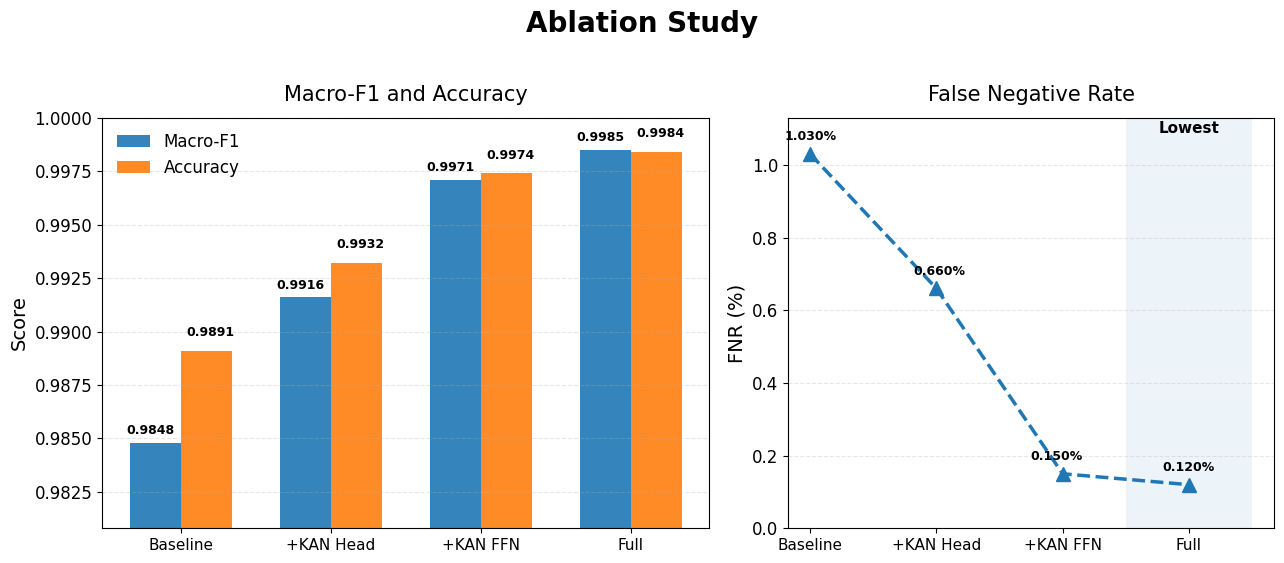

In [35]:
stages = ["Baseline", "+KAN Head", "+KAN FFN", "Full"]

macro_f1 =  [0.9848, 0.9916, 0.9971, 0.9985]
acc      =  [0.9891, 0.9932, 0.9974, 0.9984]
fnr      =  [1.03,   0.66,   0.15,   0.12]


params = ["1.13M", "1.25M", "2.90M", "3.02M"]

plot_ivn_ablation_pro(
    stages=stages,
    macro_f1=macro_f1,
    acc=acc,
    fnr_percent=fnr,
    params_text=None,
    title="Ablation Study",
    save_path=None,
)